In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerie caricate con successo!")

# Nomi delle colonne (il file non ha header)
column_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'own_telephone', 'foreign_worker', 'target'
]

file_path = os.path.join('data', 'german.data')
df = pd.read_csv(file_path, sep=' ', header=None, names=column_names)


df['target'] = df['target'].map({1: 0, 2: 1})

print("✅ Dataset caricato con successo!")
print(f"Dimensioni del dataset: {df.shape[0]} righe e {df.shape[1]} colonne.")
df.head()


✅ Librerie caricate con successo!
✅ Dataset caricato con successo!
Dimensioni del dataset: 1000 righe e 21 colonne.


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


Valori mancanti per colonna:
Series([], dtype: int64)

✅ Nessun valore mancante nel dataset.


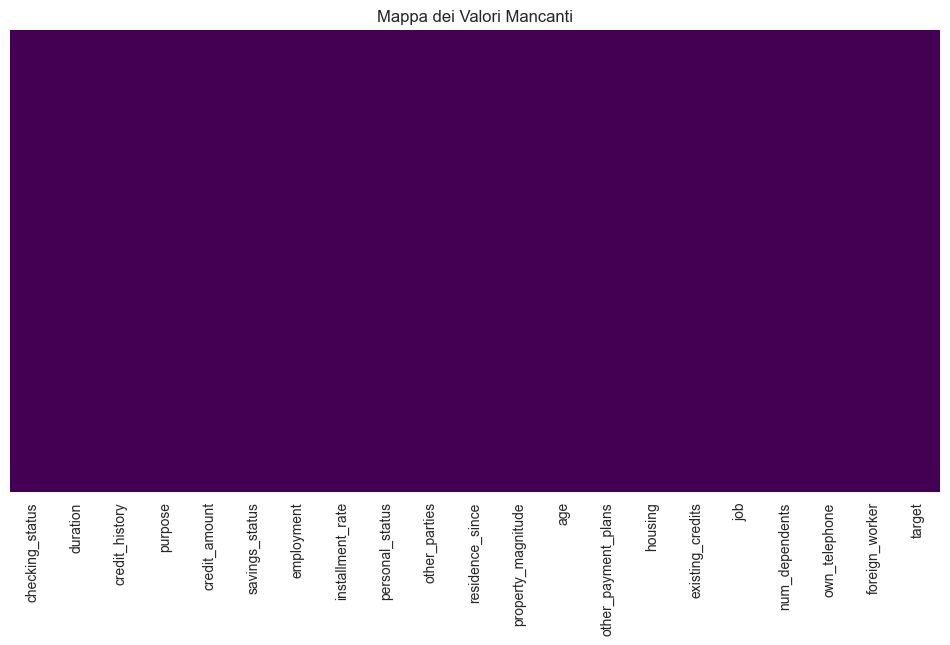

In [2]:

print("Valori mancanti per colonna:")
missing = df.isnull().sum()
print(missing[missing > 0])

if missing.sum() == 0:
    print("\n✅ Nessun valore mancante nel dataset.")


plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mappa dei Valori Mancanti')
plt.savefig('outputs/missing_heatmap.png')
plt.show()

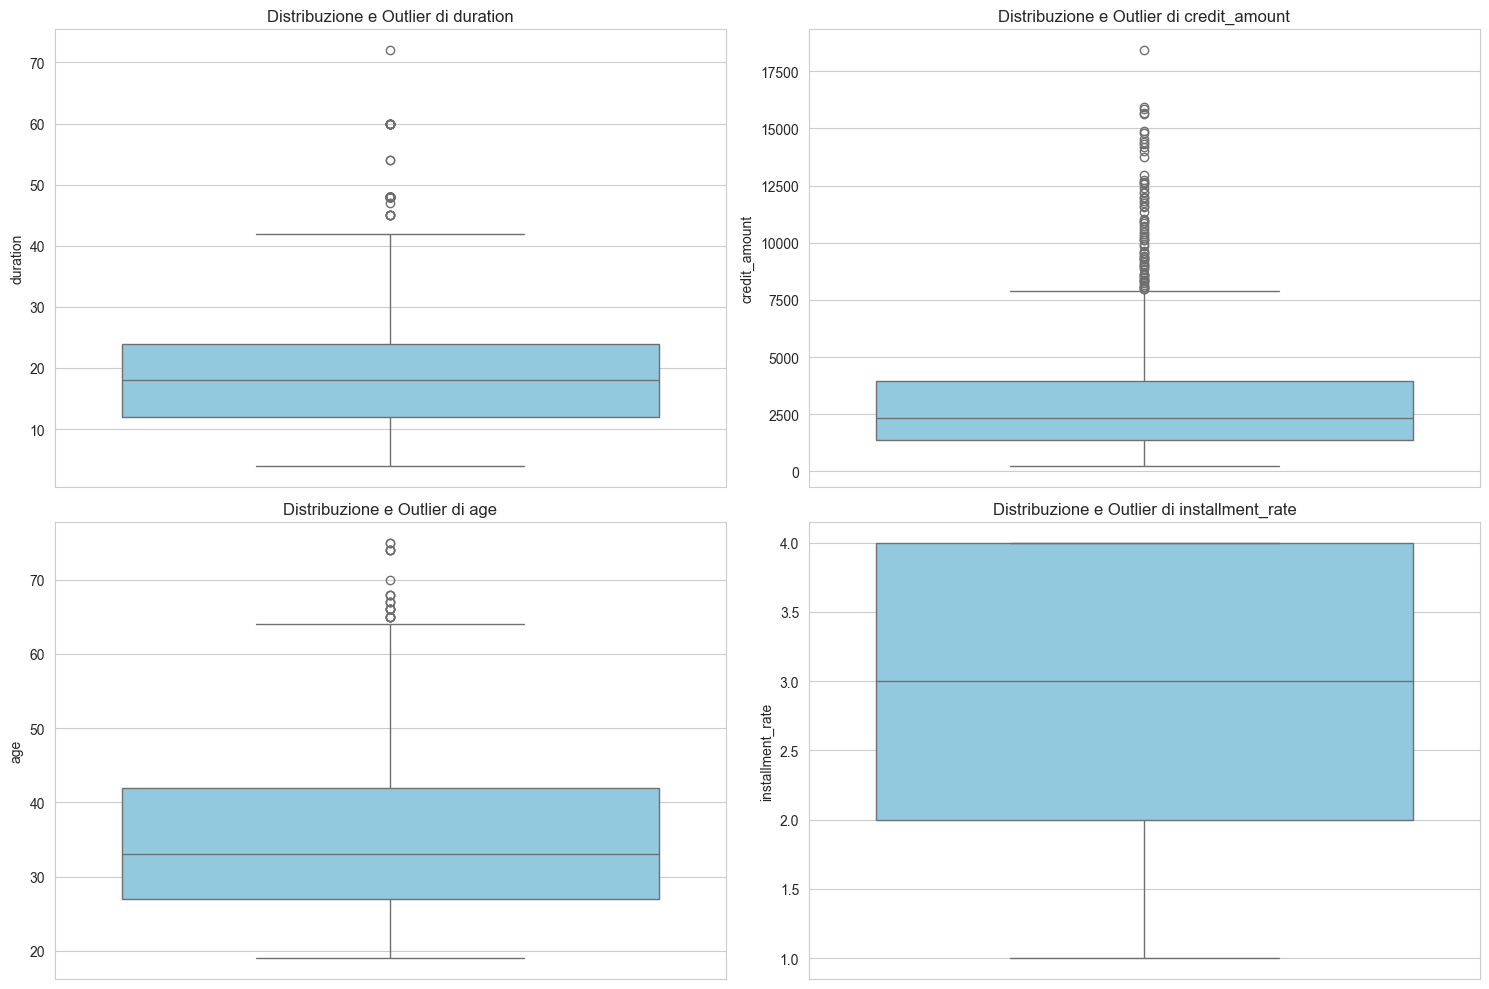

In [3]:

features_to_check = ['duration', 'credit_amount', 'age', 'installment_rate']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_check):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribuzione e Outlier di {col}')

plt.tight_layout()
plt.show()

In [4]:
# Ho scelto un dataset con troppe colonne mi sa
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Colonne categoriche da codificare: {categorical_cols}")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("✅ Encoding completato! Ecco i nuovi dati:")
display(df.head())
print(f"\nDimensioni dopo l'encoding: {df.shape[0]} righe e {df.shape[1]} colonne.")

Colonne categoriche da codificare: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
✅ Encoding completato! Ecco i nuovi dati:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target,checking_status_A12,checking_status_A13,...,property_magnitude_A124,other_payment_plans_A142,other_payment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,own_telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False



Dimensioni dopo l'encoding: 1000 righe e 49 colonne.


In [5]:
from sklearn.model_selection import train_test_split


X = df.drop('target', axis=1)  # Tutte le colonne tranne il target
y = df['target']  # Solo la sfaccimma del target

#2. Divisione 80% Train e 20% Test
# random_state=42 serve per rendere i risultati riproducibili
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Divisione completata!")
print(f"Campioni di addestramento: {X_train.shape[0]}")
print(f"Campioni di test: {X_test.shape[0]}")

✅ Divisione completata!
Campioni di addestramento: 800
Campioni di test: 200


✅ Modello Random Forest addestrato con successo!

--- Report di classificazione ---
              precision    recall  f1-score   support

           0       0.77      0.96      0.86       140
           1       0.78      0.35      0.48        60

    accuracy                           0.78       200
   macro avg       0.78      0.65      0.67       200
weighted avg       0.78      0.78      0.74       200



<Figure size 800x600 with 0 Axes>

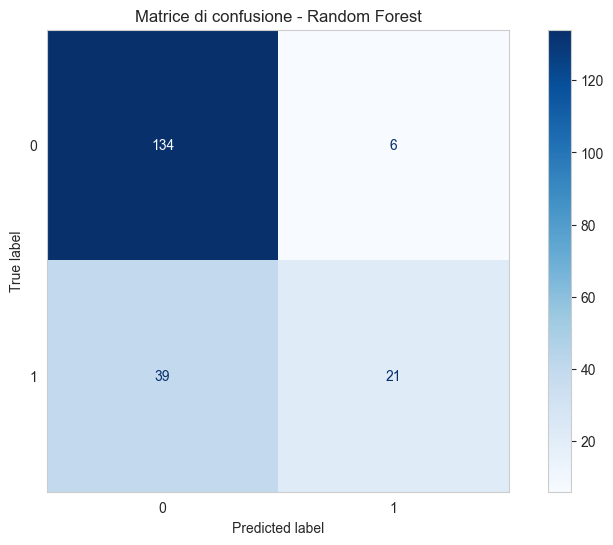

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# A. Creazione del modello
# n_estimators=100: usiamo 100 alberi decisionali (la "saggezza della folla")
# random_state=42: garantisce che i risultati siano uguali ogni volta che lo esegui
# class_weight='balanced': utile perché le classi non sono perfettamente bilanciate (70% good, 30% bad)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# B. Addestramento (Training)
model.fit(X_train, y_train)

# C. Previsione (Prediction)
y_pred = model.predict(X_test)

print("✅ Modello Random Forest addestrato con successo!")

# Report numerico (Precision, Recall, F1)
print("\n--- Report di classificazione ---")
print(classification_report(y_test, y_pred))

# Matrice di confusione grafica
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Matrice di confusione - Random Forest")
plt.grid(False)
plt.show()

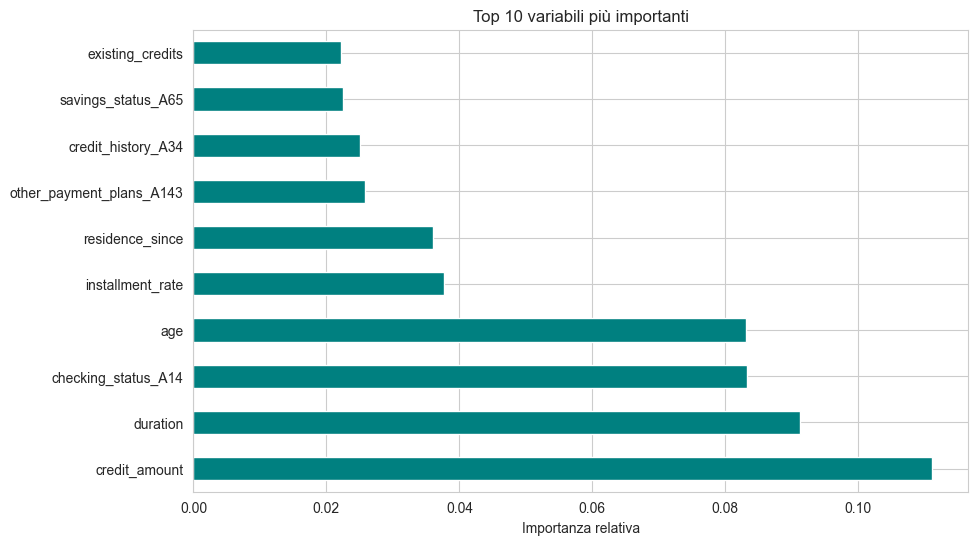

In [7]:
# Calcolo importanza 
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 variabili più importanti")
plt.xlabel("Importanza relativa")
plt.savefig('outputs/feature_importance.png')
plt.show()

--- Matrice di Confusione con Soglia 0.3 ---


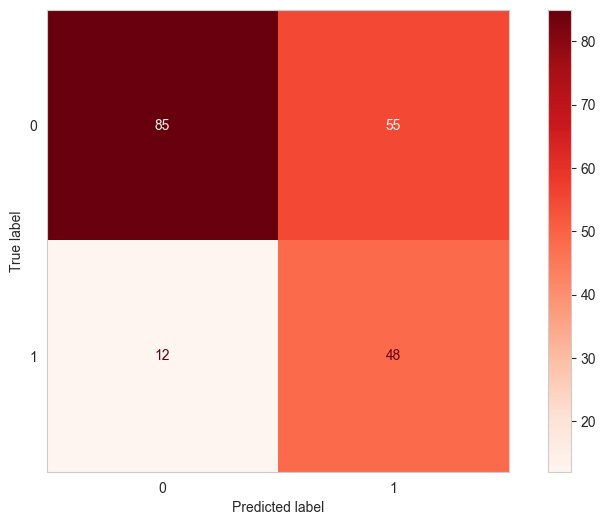

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_probs = model.predict_proba(X_test)[:, 1]


nuova_soglia = 0.30
y_pred_prudente = (y_probs >= nuova_soglia).astype(int)


print(f"--- Matrice di Confusione con Soglia {nuova_soglia} ---")
cm_prudente = confusion_matrix(y_test, y_pred_prudente)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_prudente, display_labels=model.classes_)
disp.plot(cmap='Reds')
plt.grid(False)
plt.show()

--- Confronto Performance Modelli ---
      Modello  Accuracy  Recall (Classe 1)  F1-Score (Classe 1)
Decision Tree     0.640           0.466667             0.437500
  Naive Bayes     0.740           0.650000             0.600000
Random Forest     0.775           0.350000             0.482759


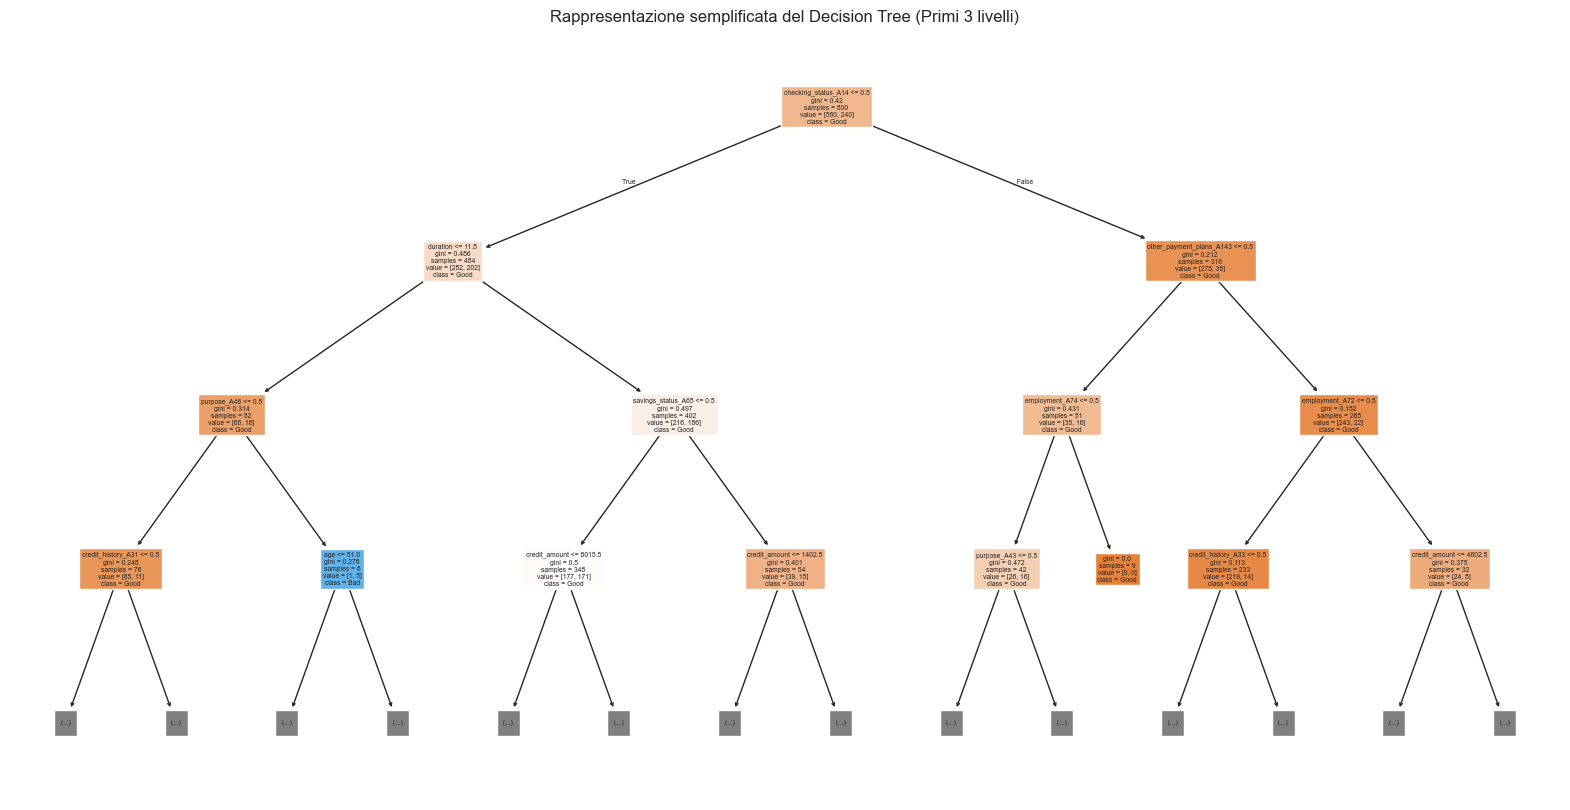

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.tree import plot_tree


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": model  
}

results = []


for name, clf in models.items():
    if name != "Random Forest":  
        clf.fit(X_train, y_train)

    y_pred_current = clf.predict(X_test)

    results.append({
        "Modello": name,
        "Accuracy": accuracy_score(y_test, y_pred_current),
        "Recall (Classe 1)": recall_score(y_test, y_pred_current),
        "F1-Score (Classe 1)": f1_score(y_test, y_pred_current)
    })


df_results = pd.DataFrame(results)
print("--- Confronto Performance Modelli ---")
print(df_results.to_string(index=False))


plt.figure(figsize=(20, 10))
plot_tree(models["Decision Tree"], max_depth=3, feature_names=X.columns, filled=True, class_names=['Good', 'Bad'])
plt.title("Rappresentazione semplificata del Decision Tree (Primi 3 livelli)")
plt.show()